In [5]:
from inspect import FrameInfo
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, Binarizer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    precision_recall_curve, roc_curve, roc_auc_score
)


font_path = '/content/drive/MyDrive/kwukdt/data-analysis/data-pre-processing/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
mpl.rc('font', family = 'NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

Mounted at /content/drive


In [6]:
# https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
diabetes_data = pd.read_csv('/content/drive/MyDrive/kwukdt/ML/data/diabetes.csv')
print(diabetes_data.shape)
diabetes_data.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=156)

lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train, y_train)

pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]
pred_proba

array([0.66171467, 0.35911512, 0.26327843, 0.48372522, 0.05290175,
       0.73085612, 0.71886704, 0.25950047, 0.57920039, 0.13266596,
       0.49344805, 0.13087069, 0.1788264 , 0.36315928, 0.53206027,
       0.71029852, 0.15363226, 0.21797288, 0.05343927, 0.27142442,
       0.11921165, 0.52278749, 0.16776135, 0.23632886, 0.13812781,
       0.17770846, 0.09693949, 0.16501702, 0.85332679, 0.72154175,
       0.60978514, 0.14597799, 0.11460065, 0.71329945, 0.7394641 ,
       0.39420764, 0.24979132, 0.294336  , 0.23732076, 0.06668945,
       0.22466441, 0.35093093, 0.44120318, 0.1294203 , 0.61258025,
       0.19152939, 0.26883864, 0.1347867 , 0.31916773, 0.14122469,
       0.27193675, 0.31404038, 0.19955067, 0.80625204, 0.83713826,
       0.73512188, 0.48768683, 0.38796585, 0.2123276 , 0.27395574,
       0.65008528, 0.43698406, 0.69619111, 0.04981941, 0.2869694 ,
       0.50104193, 0.15422713, 0.42099431, 0.19561466, 0.12201914,
       0.07702691, 0.47135757, 0.22129361, 0.33383323, 0.77974

In [8]:
print("전처리 전 로지스틱 회귀 성능")
confusion = confusion_matrix(y_test, pred)
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print("오차 행렬:")
print(confusion)
print(f"정확도: {accuracy:.4f}")
print(f"정밀도: {precision:.4f}")
print(f"재현율: {recall:.4f}")
print(f"F1 스코어: {f1:.4f}")

전처리 전 로지스틱 회귀 성능
오차 행렬:
[[87 10]
 [26 31]]
정확도: 0.7662
정밀도: 0.7561
재현율: 0.5439
F1 스코어: 0.6327


In [9]:
# ROC-AUC 스코어 계산 및 출력
roc_auc = roc_auc_score(y_test, pred_proba)
print(f'ROC-AUC 스코어: {roc_auc:.4f}')

ROC-AUC 스코어: 0.8343


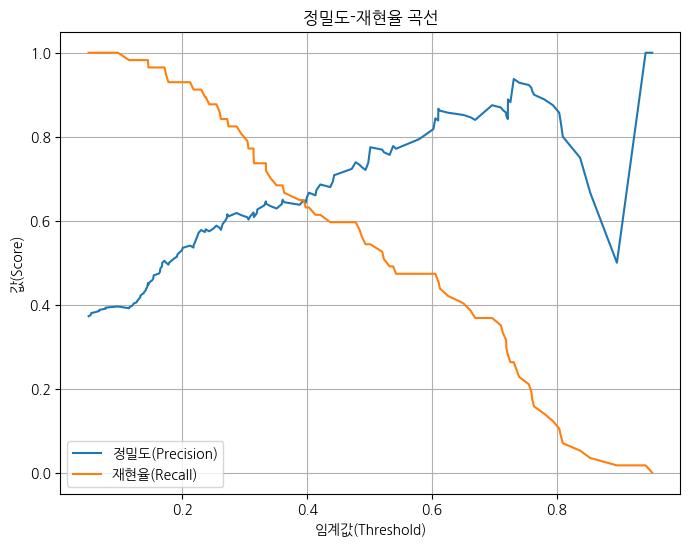

In [10]:
# 정밀도-재현율 곡선 데이터 추출
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba)

# 정밀도-재현율 곡선 시각화
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[1:], label='정밀도(Precision)')
plt.plot(thresholds, recalls[1:], label='재현율(Recall)')
plt.xlabel('임계값(Threshold)')
plt.ylabel('값(Score)')
plt.title('정밀도-재현율 곡선')
plt.legend()
plt.grid(True)
plt.show()

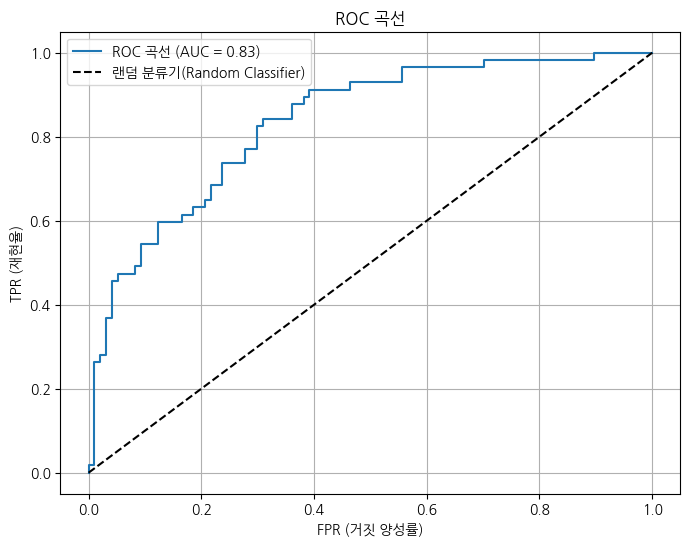

In [11]:
# ROC 곡선 데이터 추출
fpr, tpr, thresholds = roc_curve(y_test, pred_proba)

# ROC 곡선 시각화
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC 곡선 (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='랜덤 분류기(Random Classifier)')
plt.xlabel('FPR (거짓 양성률)')
plt.ylabel('TPR (재현율)')
plt.title('ROC 곡선')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# 0 값이 의미 없는 컬럼들 (결측치로 간주될 수 있는 컬럼)
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 0 값을 NaN으로 대체
diabetes_data_processed = diabetes_data.copy()
diabetes_data_processed[zero_features] = diabetes_data_processed[zero_features].replace(0, np.nan)

# NaN 값 포함된 행 삭제
diabetes_data_processed.dropna(inplace=True)

print("전처리 후 데이터 상위 5행:")
display(diabetes_data_processed.head())

전처리 후 데이터 상위 5행:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
13,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 특성 데이터와 타겟 데이터 분리
X_processed = diabetes_data_processed.iloc[:, :-1]
y_processed = diabetes_data_processed.iloc[:, -1]

# 훈련 세트와 테스트 세트 분리
X_train_processed, X_test_processed, y_train_processed, y_test_processed = train_test_split(X_processed, y_processed, test_size=0.2, random_state=156)

# StandardScaler를 이용하여 특성 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

print("스케일링된 훈련 데이터 상위 5행:")
display(pd.DataFrame(X_train_scaled, columns=X_train_processed.columns).head())

스케일링된 훈련 데이터 상위 5행:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.102510,-1.411461,-1.647118,0.210258,-0.563158,-0.343144,-0.793077,-0.483523
1,1.713666,1.111005,1.250123,-0.159465,-0.008360,0.122236,1.839842,1.131876
2,-0.707903,0.367201,2.537786,-0.159465,-0.132568,-0.089300,-0.832249,1.434764
3,-0.707903,-0.182567,0.606292,-0.067034,0.198654,0.376080,-0.099173,-0.584486
4,-1.010599,0.140826,1.250123,-0.251896,-0.298180,-0.850833,-0.046011,-0.988335


In [27]:
# 전처리된 데이터로 로지스틱 회귀 모델 재학습
lr_clf_processed = LogisticRegression(solver='liblinear')
lr_clf_processed.fit(X_train_scaled, y_train_processed)

# 예측 및 예측 확률 계산
pred_processed = lr_clf_processed.predict(X_test_scaled)
pred_proba_processed = lr_clf_processed.predict_proba(X_test_scaled)[:, 1]

print("전처리 후 로지스틱 회귀 성능")
confusion_processed = confusion_matrix(y_test_processed, pred_processed)
accuracy_processed = accuracy_score(y_test_processed, pred_processed)
precision_processed = precision_score(y_test_processed, pred_processed)
recall_processed = recall_score(y_test_processed, pred_processed)
f1_processed = f1_score(y_test_processed, pred_processed)

print("오차 행렬:")
print(confusion_processed)
print(f"정확도: {accuracy_processed:.4f}")
print(f"정밀도: {precision_processed:.4f}")
print(f"재현율: {recall_processed:.4f}")
print(f"F1 스코어: {f1_processed:.4f}")

전처리 후 로지스틱 회귀 성능
오차 행렬:
[[44 11]
 [13 11]]
정확도: 0.6962
정밀도: 0.5000
재현율: 0.4583
F1 스코어: 0.4783


In [21]:
# ROC-AUC 스코어 계산 및 출력 (전처리 후)
roc_auc_processed = roc_auc_score(y_test_processed, pred_proba_processed)
print(f'전처리 후 ROC-AUC 스코어: {roc_auc_processed:.4f}')

전처리 후 ROC-AUC 스코어: 0.7333


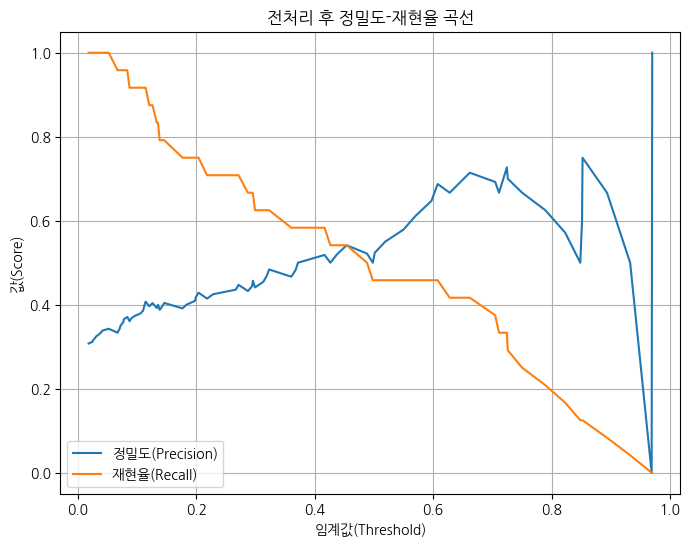

In [22]:
# 정밀도-재현율 곡선 데이터 추출 (전처리 후)
precisions_processed, recalls_processed, thresholds_processed = precision_recall_curve(y_test_processed, pred_proba_processed)

# 정밀도-재현율 곡선 시각화
plt.figure(figsize=(8, 6))
plt.plot(thresholds_processed, precisions_processed[1:], label='정밀도(Precision)')
plt.plot(thresholds_processed, recalls_processed[1:], label='재현율(Recall)')
plt.xlabel('임계값(Threshold)')
plt.ylabel('값(Score)')
plt.title('전처리 후 정밀도-재현율 곡선')
plt.legend()
plt.grid(True)
plt.show()

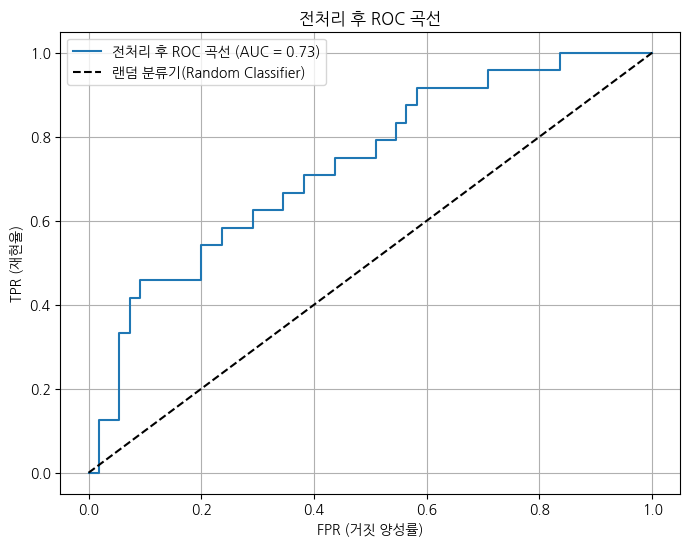

In [23]:
# ROC 곡선 데이터 추출 (전처리 후)
fpr_processed, tpr_processed, thresholds_processed_roc = roc_curve(y_test_processed, pred_proba_processed)

# ROC 곡선 시각화
plt.figure(figsize=(8, 6))
plt.plot(fpr_processed, tpr_processed, label=f'전처리 후 ROC 곡선 (AUC = {roc_auc_processed:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='랜덤 분류기(Random Classifier)')
plt.xlabel('FPR (거짓 양성률)')
plt.ylabel('TPR (재현율)')
plt.title('전처리 후 ROC 곡선')
plt.legend()
plt.grid(True)
plt.show()